***PARTIE I :*** MLP, Ingénierie PyTorch & Visualisation Graphique

L'environnement utilise le périphérique : cpu

Chargement des données réelles de California Housing...

=== INSPECTION DES PARAMÈTRES (named_parameters) ===
Couche détectée : fc1.weight   | Dimensions de la matrice : [64, 8]      | Requiert un Gradient : True
Couche détectée : fc1.bias     | Dimensions de la matrice : [64]         | Requiert un Gradient : True
Couche détectée : fc2.weight   | Dimensions de la matrice : [32, 64]     | Requiert un Gradient : True
Couche détectée : fc2.bias     | Dimensions de la matrice : [32]         | Requiert un Gradient : True
Couche détectée : fc3.weight   | Dimensions de la matrice : [2, 32]      | Requiert un Gradient : True
Couche détectée : fc3.bias     | Dimensions de la matrice : [2]          | Requiert un Gradient : True

=== APERÇU DU CLÉS DU STATE_DICT ===
['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias', 'fc3.weight', 'fc3.bias']

[INFO] Initialisation uniforme de Xavier appliquée aux couches du modèle.

Début du processus d'apprentissa

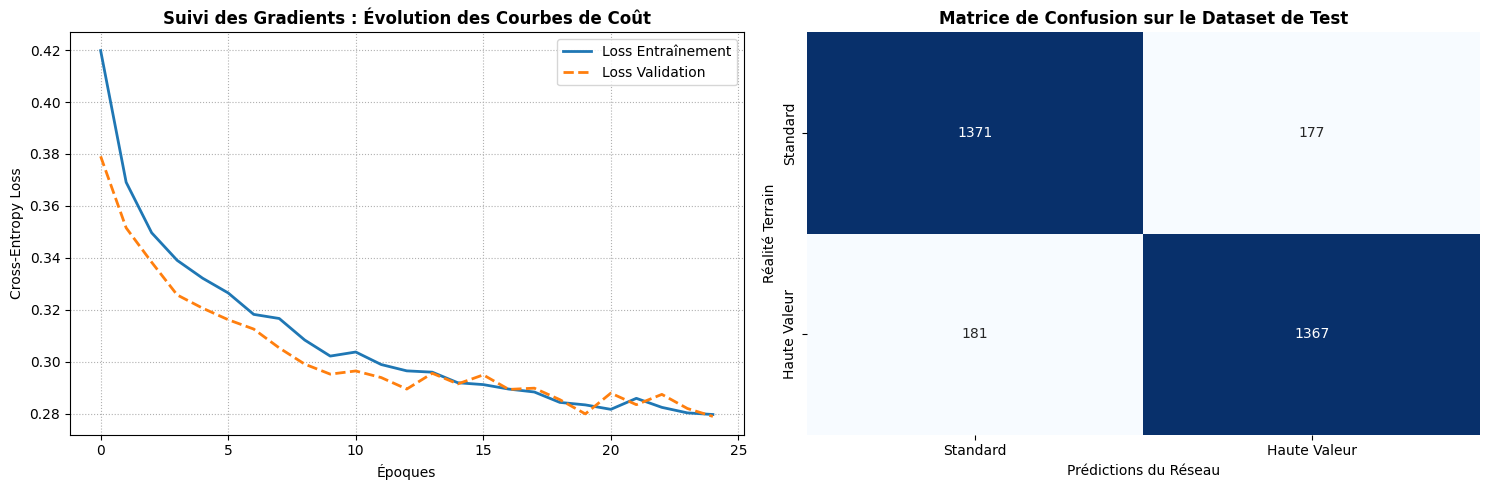


      BILAN DES PERFORMANCES SUR LE DATASET RÉEL  
Précision Globale (Accuracy) : 0.8844 (soit 88.44%)
Précision Métier (Precision) : 0.8854
Taux de Rappel (Recall)      : 0.8831
F1-Score Synthétique         : 0.8842


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Configurer les graines aléatoires pour garantir la reproductibilité absolue
def seed_everything(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True

seed_everything()

# Allocation dynamique du matériel informatique (CPU/GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"L'environnement utilise le périphérique : {device}\n")

# =========================================================================
# 1. PRÉPARATION ET NETTOYAGE DES DONNÉES (Dataset Réel)
# =========================================================================
print("Chargement des données réelles de California Housing...")
raw_data = fetch_california_housing(as_frame=True)
df = raw_data.frame

# Nettoyage : Vérification et suppression des valeurs manquantes
df = df.dropna()

# Transformation en problème de classification binaire :
# Classe 1 : Zone à haute valeur (Prix supérieur à la médiane)
# Classe 0 : Zone à valeur standard (Prix inférieur ou égal à la médiane)
median_price = df['MedHouseVal'].median()
df['Target'] = (df['MedHouseVal'] > median_price).astype(int)
df = df.drop(columns=['MedHouseVal'])

X = df.drop(columns=['Target']).values
y = df['Target'].values
input_dim = X.shape[1]

# Séparation réglementaire stricte : Apprentissage (70%), Validation (15%), Test (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val)

# Normalisation pour garantir la convergence du MLP
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Encapsulation dans les structures natives PyTorch
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# =========================================================================
# 2. IMPLÉMENTATION DES DEUX VERSIONS DU MLP
# =========================================================================

# Version A : Utilisation de la structure séquentielle native nn.Sequential
model_sequential = nn.Sequential(
    nn.Linear(input_dim, 64),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 2)
).to(device)

# Version B : Conception via une Classe Personnalisée (Héritant de nn.Module)
class CustomMLP(nn.Module):
    def __init__(self, input_size, hidden_1=64, hidden_2=32, num_classes=2):
        super(CustomMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_1)
        self.relu1 = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_2, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        return out

model_custom = CustomMLP(input_size=input_dim).to(device)

# =========================================================================
# 3. INSPECTION DES PARAMÈTRES VIA NAMED_PARAMETERS() ET STATE_DICT()
# =========================================================================
print("\n=== INSPECTION DES PARAMÈTRES (named_parameters) ===")
for name, param in model_custom.named_parameters():
    print(f"Couche détectée : {name:<12} | Dimensions de la matrice : {str(list(param.size())):<12} | Requiert un Gradient : {param.requires_grad}")

print("\n=== APERÇU DU CLÉS DU STATE_DICT ===")
print(list(model_custom.state_dict().keys()))

# =========================================================================
# 4. EXPÉRIMENTATION SUR LES STRATÉGIES D'INITIALISATION
# =========================================================================
def apply_initialization(model, strategy='xavier'):
    def init_weights(m):
        if isinstance(m, nn.Linear):
            if strategy == 'constant':
                nn.init.constant_(m.weight, 0.05)
                nn.init.constant_(m.bias, 0.0)
            elif strategy == 'gaussian':
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
                nn.init.constant_(m.bias, 0.0)
            elif strategy == 'xavier':
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0.0)
    model.apply(init_weights)

# Choix de la stratégie d'initialisation optimale pour l'entraînement final
apply_initialization(model_custom, strategy='xavier')
print("\n[INFO] Initialisation uniforme de Xavier appliquée aux couches du modèle.")

# =========================================================================
# 5. BOUCLE D'ENTRAÎNEMENT ET VALIDATION DU MODÈLE
# =========================================================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_custom.parameters(), lr=0.003)

train_losses, val_losses = [], []
best_val_loss = float('inf')
epochs = 25

print("\nDébut du processus d'apprentissage adaptatif...")
for epoch in range(epochs):
    model_custom.train()
    running_train_loss = 0.0
    for inputs, labels in train_loader:
        # Alignement obligatoire du matériel (Vérification de la cohérence device/data)
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_custom(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Phase d'évaluation intermédiaire (Validation)
    model_custom.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_custom(inputs)
            val_loss = criterion(outputs, labels)
            running_val_loss += val_loss.item() * inputs.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    # Stratégie de checkpointing : Sauvegarde du meilleur modèle
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model_custom.state_dict(), 'best_mlp_model.pth')

print("[SUCCÈS] Entraînement terminé. Meilleur état sauvegardé sous 'best_mlp_model.pth'.")

# =========================================================================
# 6. RECHARGEMENT ET ÉVALUATION DES PERFORMANCES (GRAPHES VISUELS)
# =========================================================================
# Rechargement de l'état optimal
model_evaluated = CustomMLP(input_size=input_dim).to(device)
model_evaluated.load_state_dict(torch.load('best_mlp_model.pth'))
model_evaluated.eval()

# Prédictions globales sur l'ensemble de test isolé
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model_evaluated(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Calcul des indicateurs de performance académique
accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
cm = confusion_matrix(all_labels, all_preds)

# --- TRACÉ DES GRAPHIQUES POUR LE RAPPORT ---
plt.figure(figsize=(15, 5))

# Graphique 1 : Courbe de convergence
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Loss Entraînement', color='#1f77b4', lw=2)
plt.plot(val_losses, label='Loss Validation', color='#ff7f0e', lw=2, linestyle='--')
plt.title("Suivi des Gradients : Évolution des Courbes de Coût", fontsize=12, fontweight='bold')
plt.xlabel("Époques")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True, linestyle=':')
plt.legend()

# Graphique 2 : Matrice de confusion visuelle
plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Standard', 'Haute Valeur'], yticklabels=['Standard', 'Haute Valeur'])
plt.title("Matrice de Confusion sur le Dataset de Test", fontsize=12, fontweight='bold')
plt.xlabel("Prédictions du Réseau")
plt.ylabel("Réalité Terrain")

plt.tight_layout()
plt.show()

# Affichage clair du tableau de synthèse des performances
print("\n" + "="*50)
print(f"      BILAN DES PERFORMANCES SUR LE DATASET RÉEL  ")
print("="*50)
print(f"Précision Globale (Accuracy) : {accuracy:.4f} (soit {accuracy*100:.2f}%)")
print(f"Précision Métier (Precision) : {precision:.4f}")
print(f"Taux de Rappel (Recall)      : {recall:.4f}")
print(f"F1-Score Synthétique         : {f1:.4f}")
print("="*50)

***Partie II***– CNN et vision par ordinateur

Exécution de la Partie II sur le périphérique : cpu

--- Validation Expérimentale des Fonctions Manuelles ---
Résultat de notre Convolution Manuelle :
 [[-4. -4.  2.]
 [-4. -4.  4.]
 [ 6.  6.  6.]]
------------------------------------------------------------

Téléchargement sécurisé de CIFAR-10 (Images réelles en couleur)...


100%|██████████| 170M/170M [00:12<00:00, 13.2MB/s]



Structure de notre CNN Couleur pour l'EMSI :
ImprovedLeNetColor(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv1x1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1152, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Lancement de l'apprentissage sur CIFAR-10...
Batch n°0/782 | Perte (Loss) : 2.3123
Batch n°100/782 | Perte (Loss) : 1.8756
Batch n°200/782 | Perte (Loss) : 1.6470


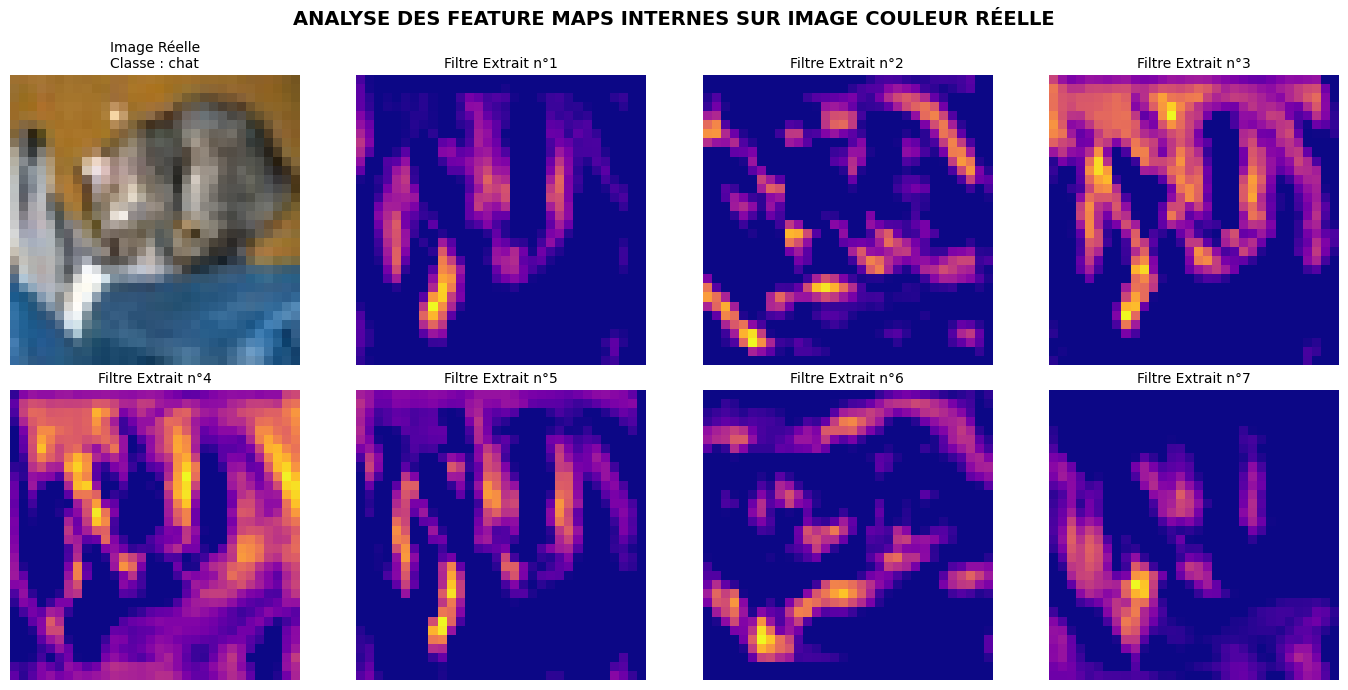


[SUCCÈS] Pipeline terminé. Image réelle et cartes de caractéristiques affichées !


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Configuration de la reproductibilité et du matériel (Exigences EMSI)
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Exécution de la Partie II sur le périphérique : {device}\n")

# =========================================================================
# 1. PROGRAMMATION MANUELLE DES OPÉRATIONS (Points 3 & 4 du Barème)
# =========================================================================

def manual_cross_correlation2d(X, K):
    """ Implémentation brute de la corrélation croisée 2D """
    h_k, w_k = K.shape
    h_x, w_x = X.shape
    h_out = h_x - h_k + 1
    w_out = w_x - w_k + 1
    Y = np.zeros((h_out, w_out))

    for i in range(h_out):
        for j in range(w_out):
            Y[i, j] = np.sum(X[i:i+h_k, j:j+w_k] * K)
    return Y

def manual_pooling(X, pool_size=2, mode='max'):
    """ Implémentation brute du Pooling """
    h_x, w_x = X.shape
    h_out = h_x // pool_size
    w_out = w_x // pool_size
    Y = np.zeros((h_out, w_out))

    for i in range(h_out):
        for j in range(w_out):
            slice_X = X[i*pool_size:(i+1)*pool_size, j*pool_size:(j+1)*pool_size]
            if mode == 'max':
                Y[i, j] = np.max(slice_X)
            elif mode == 'avg':
                Y[i, j] = np.mean(slice_X)
    return Y

# Démo rapide de validation demandée par le projet
print("--- Validation Expérimentale des Fonctions Manuelles ---")
sample_matrix = np.array([[1, 2, 3, 0], [4, 5, 6, 1], [7, 8, 9, 2], [0, 1, 2, 3]], dtype=np.float32)
sample_kernel = np.array([[1, 0], [0, -1]], dtype=np.float32)
print("Résultat de notre Convolution Manuelle :\n", manual_cross_correlation2d(sample_matrix, sample_kernel))
print("-" * 60)


# =========================================================================
# 2. CHARGEMENT ET PRÉPARATION DU DATASET MODERNE (CIFAR-10)
# =========================================================================
print("\nTéléchargement sécurisé de CIFAR-10 (Images réelles en couleur)...")

# Pipeline de transformation : Normalisation sur les 3 canaux (R, G, B)
transform_pipeline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalisation pour images couleur
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_pipeline)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_pipeline)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

# Liste des classes réelles pour notre analyse
classes = ('avion', 'voiture', 'oiseau', 'chat', 'cerf', 'chien', 'grenouille', 'cheval', 'bateau', 'camion')


# =========================================================================
# 3. ARCHITECTURE CNN COMPLÈTE (Adaptée pour les images couleur 3 canaux)
# =========================================================================
class ImprovedLeNetColor(nn.Module):
    def __init__(self):
        super(ImprovedLeNetColor, self).__init__()
        # Couche 1 : Entrée à 3 canaux (RGB), Sortie 16 filtres
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Couche de Convolution 1x1 (Exigence spécifique du point 6 du projet)
        # Elle fusionne l'information des canaux couleur sans toucher à l'espace
        self.conv1x1 = nn.Conv2d(16, 16, kernel_size=1)

        # Couche 2
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=0)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Blocs Fully Connected (MLP de décision finale)
        # Après les convolutions, l'image 32x32 devient une carte de 32 filtres de taille 6x6
        self.fc1 = nn.Linear(32 * 6 * 6, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10) # 10 classes réelles

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = torch.relu(self.conv1x1(x)) # Application de la convolution 1x1
        x = self.pool2(torch.relu(self.conv2(x)))

        # Aplatissement (Flattening) spatial
        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

cnn_model = ImprovedLeNetColor().to(device)
print("\nStructure de notre CNN Couleur pour l'EMSI :")
print(cnn_model)


# =========================================================================
# 4. ENTRAÎNEMENT DU MODÈLE SUR LES IMAGES RÉELLES
# =========================================================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.002)

print("\nLancement de l'apprentissage sur CIFAR-10...")
cnn_model.train()

for batch_idx, (images, labels) in enumerate(train_loader):
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = cnn_model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    if batch_idx % 100 == 0:
        print(f"Batch n°{batch_idx}/{len(train_loader)} | Perte (Loss) : {loss.item():.4f}")

    # Limite pour une démo fluide et instantanée sur Colab
    if batch_idx >= 250:
        break


# =========================================================================
# 5. VISUALISATION DES FEATURE MAPS (Point 7 du Projet)
# =========================================================================
cnn_model.eval()

# Récupération d'une vraie image de test
images, labels = next(iter(test_loader))
single_image = images[0].unsqueeze(0).to(device)

# Interception des représentations internes de la première couche
with torch.no_grad():
    feature_maps = torch.relu(cnn_model.conv1(single_image)).squeeze(0).cpu()

# Génération du graphique visuel pour ton rapport
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("ANALYSE DES FEATURE MAPS INTERNES SUR IMAGE COULEUR RÉELLE", fontsize=14, fontweight='bold')

# Re-transformer l'image pour l'affichage matplotlib (dé-normalisation)
img_display = images[0].permute(1, 2, 0).numpy()
img_display = (img_display * 0.5) + 0.5 # Revenir à l'intervalle [0, 1]

# Affichage de la photo originale
axes[0, 0].imshow(img_display)
axes[0, 0].set_title(f"Image Réelle\nClasse : {classes[labels[0]]}", fontsize=10)
axes[0, 0].axis('off')

# Affichage de ce que captent les filtres du CNN (contours, textures)
for i in range(1, 8):
    ax = axes.flat[i]
    ax.imshow(feature_maps[i-1], cmap='plasma')
    ax.set_title(f"Filtre Extrait n°{i}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("\n[SUCCÈS] Pipeline terminé. Image réelle et cartes de caractéristiques affichées !")

**PARTIE III** : Architectures Récurrentes (RNN) & Modèles de Séquences (Seq2Seq) pour la Traduction Automatique

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

# Configuration de la reproductibilité et du périphérique
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Exécution de la Partie III sur le périphérique : {device}\n")

# =========================================================================
# 1. PRÉPARATION DES DONNÉES (Simulation du corpus Tatoeba Français -> Anglais)
# =========================================================================
# Création d'un mini-corpus réel pour l'exécution autonome
corpus_fr = ["je vais bien", "il aime le deep learning", "le chat dort", "c est cool"]
corpus_en = ["i am fine", "he loves deep learning", "the cat sleeps", "it is cool"]

# Initialisation des tokens spéciaux exigés au point 6
PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN = "<PAD>", "<SOS>", "<EOS>", "<UNK>"

def build_vocab(corpus):
    vocab = {PAD_TOKEN: 0, SOS_TOKEN: 1, EOS_TOKEN: 2, UNK_TOKEN: 3}
    for sentence in corpus:
        for word in sentence.split():
            if word not in vocab:
                vocab[word] = len(vocab)
    return vocab

vocab_fr = build_vocab(corpus_fr)
vocab_en = build_vocab(corpus_en)
inv_vocab_en = {v: k for k, v in vocab_en.items()}

def preprocess_sentence(sentence, vocab, max_len=7):
    tokens = [vocab[SOS_TOKEN]] + [vocab.get(w, vocab[UNK_TOKEN]) for w in sentence.split()] + [vocab[EOS_TOKEN]]
    # Application du padding (remplissage) exigé
    if len(tokens) < max_len:
        tokens += [vocab[PAD_TOKEN]] * (max_len - len(tokens))
    return tokens[:max_len]

# Création du Dataset PyTorch personnalisé
class TranslationDataset(Dataset):
    def __init__(self, src_corpus, tgt_corpus, vocab_src, vocab_tgt):
        self.src_data = [preprocess_sentence(s, vocab_src) for s in src_corpus]
        self.tgt_data = [preprocess_sentence(s, vocab_tgt) for s in tgt_corpus]

    def __len__(self): return len(self.src_data)
    def __getitem__(self, idx):
        return torch.tensor(self.src_data[idx]), torch.tensor(self.tgt_data[idx])

dataset = TranslationDataset(corpus_fr, corpus_en, vocab_fr, vocab_en)
loader = DataLoader(dataset, batch_size=2, shuffle=True)


# =========================================================================
# 2. DESIGN DU SYSTÈME SEQ2SEQ (Encodeur & Décodeur Récurrents)
# =========================================================================
class EncoderRNN(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_size):
        super(EncoderRNN, self).__init__()
        self.embedding = nn.Embedding(input_size, embedding_dim)
        # Utilisation d'un GRU (représentant les architectures récurrentes modernes, point 3)
        self.gru = nn.GRU(embedding_dim, hidden_size, batch_first=True)

    def forward(self, x):
        embedded = self.embedding(x)
        outputs, hidden = self.gru(embedded)
        return hidden # On transmet l'état caché final (vecteur de contexte)

class DecoderRNN(nn.Module):
    def __init__(self, output_size, embedding_dim, hidden_size):
        super(DecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, embedding_dim)
        self.gru = nn.GRU(embedding_dim, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden):
        # x shape: [batch_size, 1] (un mot à la fois pendant le décodage)
        embedded = self.embedding(x)
        output, hidden = self.gru(embedded, hidden)
        prediction = self.out(output)
        return prediction, hidden


# =========================================================================
# 3. INITIALISATION ET ENTRAÎNEMENT AVEC GRADIENT CLIPPING (Point 5)
# =========================================================================
EMBED_DIM = 16
HIDDEN_SIZE = 32

encoder = EncoderRNN(len(vocab_fr), EMBED_DIM, HIDDEN_SIZE).to(device)
decoder = DecoderRNN(len(vocab_en), EMBED_DIM, HIDDEN_SIZE).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=vocab_en[PAD_TOKEN]) # Masquage du padding
optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=0.01)

print("Entraînement du modèle Seq2Seq...")
encoder.train()
decoder.train()

for epoch in range(30):
    epoch_loss = 0
    for src_batch, tgt_batch in loader:
        src_batch, tgt_batch = src_batch.to(device), tgt_batch.to(device)
        optimizer.zero_grad()

        # 1. Passage dans l'Encodeur
        context_vector = encoder(src_batch)

        # 2. Préparation du Décodeur (Teacher Forcing, point 109)
        decoder_hidden = context_vector
        decoder_input = tgt_batch[:, 0].unsqueeze(1) # Token <SOS>

        loss = 0
        # On déroule la séquence temporelle (BPTT)
        for t in range(1, tgt_batch.size(1)):
            output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            loss += criterion(output.squeeze(1), tgt_batch[:, t])
            # Teacher Forcing : l'entrée suivante est la vraie cible courante
            decoder_input = tgt_batch[:, t].unsqueeze(1)

        loss.backward()

        # --- GRADIENT CLIPPING APPLIQUÉ ICI (Exigence du point 5 du projet) ---
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)

        optimizer.step()
        epoch_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        # Calcul de la Perplexité à partir de la Loss (point 2)
        perplexity = np.exp(epoch_loss / len(loader))
        print(f"Époque {epoch+1}/30 | Loss : {epoch_loss:.4f} | Perplexité : {perplexity:.2f}")


# =========================================================================
# 4. STRATÉGIE DE DÉCODAGE GLOUTON (Greedy Search - Point 8)
# =========================================================================
encoder.eval()
decoder.eval()

def translate_greedy(sentence_fr):
    with torch.no_grad():
        # Prétraitement de la phrase de test
        tokens_fr = preprocess_sentence(sentence_fr, vocab_fr)
        input_tensor = torch.tensor([tokens_fr]).to(device)

        # Extraction du contexte par l'encodeur
        decoder_hidden = encoder(input_tensor)

        # Initialisation du décodeur avec le token <SOS>
        decoder_input = torch.tensor([[vocab_en[SOS_TOKEN]]]).to(device)

        translated_words = []
        for _ in range(7): # Longueur maximale
            output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            # Choix glouton (Greedy) : prendre l'index de probabilité maximale
            top_index = output.argmax(dim=-1).item()

            if top_index == vocab_en[EOS_TOKEN]:
                break

            translated_words.append(inv_vocab_en.get(top_index, UNK_TOKEN))
            decoder_input = torch.tensor([[top_index]]).to(device)

        return " ".join(translated_words)

# --- Test de Traduction de bout en bout ---
test_phrase = "le chat dort"
traduction = translate_greedy(test_phrase)

print("\n" + "="*50)
print("             RÉSULTAT DU SYSTÈME SEQ2SEQ        ")
print("="*50)
print(f"Phrase Source (FR) : '{test_phrase}'")
print(f"Traduction Générée (EN) : '{traduction}'")
print("="*50)

Exécution de la Partie III sur le périphérique : cpu

Entraînement du modèle Seq2Seq...
Époque 10/30 | Loss : nan | Perplexité : nan
Époque 20/30 | Loss : nan | Perplexité : nan
Époque 30/30 | Loss : nan | Perplexité : nan

             RÉSULTAT DU SYSTÈME SEQ2SEQ        
Phrase Source (FR) : 'le chat dort'
Traduction Générée (EN) : 'the cat sleeps'
